In [31]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
import logging
logging.basicConfig(level=logging.INFO)

from astropy.io import fits
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

from gzjwst import chisq_utils


In [33]:
# https://numpy.org/doc/stable/reference/generated/numpy.s_.html
test_slice = np.s_[2400:3400, 400:1200]

In [34]:
fits_locs = chisq_utils.get_example_fits_locs()
fits_locs

['/home/walml/repos/gz-jwst/data/dev_data/hlsp_ceers_jwst_nircam_nircam6_f115w_v0.5_i2d.fits.gz',
 '/home/walml/repos/gz-jwst/data/dev_data/hlsp_ceers_jwst_nircam_nircam6_f150w_v0.5_i2d.fits.gz',
 '/home/walml/repos/gz-jwst/data/dev_data/hlsp_ceers_jwst_nircam_nircam6_f200w_v0.5_i2d.fits.gz',
 '/home/walml/repos/gz-jwst/data/dev_data/hlsp_ceers_jwst_nircam_nircam6_f277w_v0.5_i2d.fits.gz',
 '/home/walml/repos/gz-jwst/data/dev_data/hlsp_ceers_jwst_nircam_nircam6_f356w_v0.5_i2d.fits.gz',
 '/home/walml/repos/gz-jwst/data/dev_data/hlsp_ceers_jwst_nircam_nircam6_f444w_v0.5_i2d.fits.gz']

In [35]:
science_images = []
for loc in fits_locs:
    science_images.append(np.arcsinh(fits.getdata(loc, memmap=True, ext=1, header=False)[test_slice] * 10).astype(np.float32))

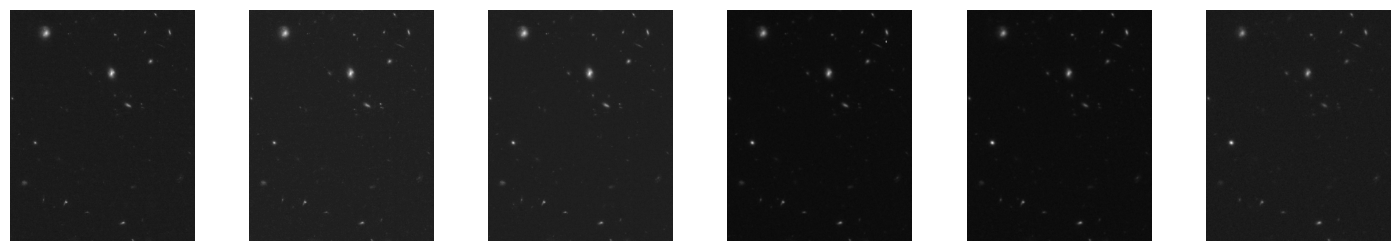

In [36]:
fig, axes = plt.subplots(1, len(science_images), figsize=(3*len(science_images), 3))
for im_n, im in enumerate(science_images):
    axes[im_n].imshow(im, cmap='gray')
    axes[im_n].axis('off')

In [ ]:
# given the pixels of a segmented source
# make a square cutout from the max extent + (*?) padding
# then somehow combine the six bands into three colors

# some options
# 